<a href="https://colab.research.google.com/github/iyadgantengg120-oss/machine-learning/blob/main/ml_p3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install statsmodels scikit-learn -q

import numpy as np
import pandas as pd
from scipy.stats import skew, pearsonr
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import mutual_info_classif
from statsmodels.stats.outliers_influence import variance_inflation_factor
pd.set_option('display.width', 120)
np.random.seed(42)

In [ ]:
!wget -q "https://raw.githubusercontent.com/JLZml/Credit-Scoring-Data-Sets/master/3.%20Kaggle/Give%20Me%20Some%20Credit/cs-training.csv" -O cs-training.csv

df_raw = pd.read_csv('cs-training.csv')
print("Ukuran dataset:", df_raw.shape)
df_raw.head()

Ukuran dataset: (150000, 12)


,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
0,1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
1,2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
2,3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
3,4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
4,5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [ ]:
X = df_raw.drop(columns=['SeriousDlqin2yrs'])
y = df_raw['SeriousDlqin2yrs']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")
print("Split dilakukan SEBELUM kalkulasi statistik apa pun -> aman dari data leakage.")

X_train: (120000, 11), X_test: (30000, 11)
Split dilakukan SEBELUM kalkulasi statistik apa pun -> aman dari data leakage.


In [ ]:
uniqueness_ratio = X_train.nunique() / len(X_train)
print("Uniqueness Ratio tiap kolom:")
print(uniqueness_ratio.sort_values(ascending=False).round(4))

id_like_cols = uniqueness_ratio[uniqueness_ratio > 0.99].index.tolist()
print(f"\nKolom terindikasi ID unik: {id_like_cols}")

X_train = X_train.drop(columns=id_like_cols, errors='ignore')
X_test = X_test.drop(columns=id_like_cols, errors='ignore')
print(f"Kolom {id_like_cols} sudah di-drop.")

Uniqueness Ratio tiap kolom:
Unnamed: 0                              1.0000
RevolvingUtilizationOfUnsecuredLines    0.8411
DebtRatio                               0.7763
MonthlyIncome                           0.1056
age                                     0.0007
NumberOfOpenCreditLinesAndLoans         0.0005
NumberRealEstateLoansOrLines            0.0002
NumberOfTimes90DaysLate                 0.0002
NumberOfTime30-59DaysPastDueNotWorse    0.0001
NumberOfTime60-89DaysPastDueNotWorse    0.0001
NumberOfDependents                      0.0001
dtype: float64

Kolom terindikasi ID unik: ['Unnamed: 0']
Kolom ['Unnamed: 0'] sudah di-drop.


In [ ]:
class_counts = y_train.value_counts()
class_pct = y_train.value_counts(normalize=True) * 100
imbalance_ratio = class_counts[0] / class_counts[1]

print(f"Kelas 0 (Lancar)     : {class_counts[0]} baris ({class_pct[0]:.2f}%)")
print(f"Kelas 1 (Gagal Bayar): {class_counts[1]} baris ({class_pct[1]:.2f}%)")
print(f"Imbalance Ratio      : {imbalance_ratio:.2f} : 1")

if imbalance_ratio > 4:
    print("Rasio > 4:1 -> gunakan StratifiedKFold, metrik PR-AUC/F1-Score, class_weight='balanced'")

Kelas 0 (Lancar)     : 111979 baris (93.32%)
Kelas 1 (Gagal Bayar): 8021 baris (6.68%)
Imbalance Ratio      : 13.96 : 1
Rasio > 4:1 -> gunakan StratifiedKFold, metrik PR-AUC/F1-Score, class_weight='balanced'


In [ ]:
numeric_cols = X_train.select_dtypes(include=[np.number]).columns
skew_results = X_train[numeric_cols].apply(lambda col: skew(col.dropna()))
skew_results = skew_results.sort_values(ascending=False)
print("Skewness (Fisher-Pearson) tiap fitur:")
print(skew_results.round(3))

highly_skewed = skew_results[skew_results.abs() > 1].index.tolist()
print(f"\nFitur sangat menceng (|gamma1| > 1): {highly_skewed}")
print("Tindakan: pakai Log1p / Box-Cox / RobustScaler, JANGAN StandardScaler langsung.")

Skewness (Fisher-Pearson) tiap fitur:
MonthlyIncome                           122.588
RevolvingUtilizationOfUnsecuredLines    100.538
DebtRatio                                99.143
NumberOfTime60-89DaysPastDueNotWorse     23.394
NumberOfTimes90DaysLate                  23.156
NumberOfTime30-59DaysPastDueNotWorse     22.656
NumberRealEstateLoansOrLines              3.753
NumberOfDependents                        1.599
NumberOfOpenCreditLinesAndLoans           1.229
age                                       0.186
dtype: float64

Fitur sangat menceng (|gamma1| > 1): ['MonthlyIncome', 'RevolvingUtilizationOfUnsecuredLines', 'DebtRatio', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfTimes90DaysLate', 'NumberOfTime30-59DaysPastDueNotWorse', 'NumberRealEstateLoansOrLines', 'NumberOfDependents', 'NumberOfOpenCreditLinesAndLoans']
Tindakan: pakai Log1p / Box-Cox / RobustScaler, JANGAN StandardScaler langsung.


In [ ]:
missing_pct = X_train.isna().mean() * 100
missing_pct = missing_pct[missing_pct > 0].sort_values(ascending=False)
print("Kolom dengan missing value:")
print(missing_pct.round(2))

for col in missing_pct.index:
    is_missing = X_train[col].isna().astype(int)
    default_rate = y_train.groupby(is_missing).mean()
    print(f"\n-- Kolom '{col}' --")
    print(f"% missing: {missing_pct[col]:.2f}%")
    print(f"Rata-rata target saat TERISI: {default_rate.get(0, float('nan')):.4f}")
    print(f"Rata-rata target saat KOSONG: {default_rate.get(1, float('nan')):.4f}")

Kolom dengan missing value:
MonthlyIncome         19.73
NumberOfDependents     2.61
dtype: float64

-- Kolom 'MonthlyIncome' --
% missing: 19.73%
Rata-rata target saat TERISI: 0.0696
Rata-rata target saat KOSONG: 0.0557

-- Kolom 'NumberOfDependents' --
% missing: 2.61%
Rata-rata target saat TERISI: 0.0674
Rata-rata target saat KOSONG: 0.0441


In [ ]:
col_check = 'RevolvingUtilizationOfUnsecuredLines'
data = X_train[col_check].dropna()

z_scores = (data - data.mean()) / data.std()
outlier_z = (z_scores.abs() > 3).sum()

q1, q3 = data.quantile([0.25, 0.75])
iqr = q3 - q1
lower, upper = q1 - 1.5*iqr, q3 + 1.5*iqr
outlier_iqr = ((data < lower) | (data > upper)).sum()

median = data.median()
mad = (data - median).abs().median()
mod_z = 0.6745 * (data - median) / mad
outlier_modz = (mod_z.abs() > 3.5).sum()

print(f"Outlier via Z-score standar : {outlier_z} baris")
print(f"Outlier via IQR             : {outlier_iqr} baris")
print(f"Outlier via Modified Z-score: {outlier_modz} baris")
print("Jika Z-score jauh lebih kecil dari IQR/Modified Z-score -> masking effect terbukti.")

Outlier via Z-score standar : 151 baris
Outlier via IQR             : 617 baris
Outlier via Modified Z-score: 15097 baris
Jika Z-score jauh lebih kecil dari IQR/Modified Z-score -> masking effect terbukti.


In [ ]:
is_outlier = (data < lower) | (data > upper)
outlier_idx = data[is_outlier].index
target_in_outlier = y_train.loc[outlier_idx].mean() * 100
target_overall = y_train.mean() * 100

print(f"Rata-rata target di populasi umum : {target_overall:.2f}%")
print(f"Rata-rata target di dalam outlier : {target_in_outlier:.2f}%")

if target_in_outlier > target_overall * 1.5:
    print("STATUS: TRUE SIGNAL -> jangan dibuang, redam skala via log1p atau pakai model tree-based.")
else:
    print("STATUS: tidak menunjukkan sinyal kuat -> bisa dipertimbangkan trimming.")

Rata-rata target di populasi umum : 6.68%
Rata-rata target di dalam outlier : 32.09%
STATUS: TRUE SIGNAL -> jangan dibuang, redam skala via log1p atau pakai model tree-based.


In [ ]:
past_due_cols = [
    'NumberOfTime30-59DaysPastDueNotWorse',
    'NumberOfTimes90DaysLate',
    'NumberOfTime60-89DaysPastDueNotWorse',
    'NumberOfOpenCreditLinesAndLoans',
    'NumberRealEstateLoansOrLines'
]
X_vif = X_train[past_due_cols].fillna(X_train[past_due_cols].median())

corr_matrix = X_vif.corr(method='pearson')
print("Matriks korelasi Pearson:")
print(corr_matrix.round(3))

vif_data = pd.DataFrame()
vif_data['Feature'] = X_vif.columns
vif_data['VIF'] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
vif_data = vif_data.sort_values('VIF', ascending=False).reset_index(drop=True)
print("\nTabel VIF:")
print(vif_data.round(2))

Matriks korelasi Pearson:
                                      NumberOfTime30-59DaysPastDueNotWorse  NumberOfTimes90DaysLate  \
NumberOfTime30-59DaysPastDueNotWorse                                 1.000                    0.984   
NumberOfTimes90DaysLate                                              0.984                    1.000   
NumberOfTime60-89DaysPastDueNotWorse                                 0.987                    0.993   
NumberOfOpenCreditLinesAndLoans                                     -0.055                   -0.080   
NumberRealEstateLoansOrLines                                        -0.030                   -0.045   

                                      NumberOfTime60-89DaysPastDueNotWorse  NumberOfOpenCreditLinesAndLoans  \
NumberOfTime30-59DaysPastDueNotWorse                                 0.987                           -0.055   
NumberOfTimes90DaysLate                                              0.993                           -0.080   
NumberOfTime60-89DaysP

In [ ]:
col_check2 = 'age'
data2 = X_train[[col_check2]].fillna(X_train[col_check2].median())

pearson_r, _ = pearsonr(data2[col_check2], y_train)
mi_score = mutual_info_classif(data2, y_train, random_state=42)[0]

print(f"Korelasi Pearson (r) vs target: {pearson_r:.4f}")
print(f"Mutual Information vs target  : {mi_score:.4f}")

if abs(pearson_r) < 0.15 and mi_score > 0.001:
    print("Pearson rendah tapi MI > 0 -> indikasi hubungan NON-LINEAR, jangan drop fitur ini.")

Korelasi Pearson (r) vs target: -0.1123
Mutual Information vs target  : 0.0079
Pearson rendah tapi MI > 0 -> indikasi hubungan NON-LINEAR, jangan drop fitur ini.


In [ ]:
col_check3 = 'NumberOfTime30-59DaysPastDueNotWorse'
data3 = X_train[col_check3].dropna()
value_counts = data3.value_counts().sort_index()

print("Distribusi nilai (top 10 frekuensi tertinggi):")
print(value_counts.sort_values(ascending=False).head(10))

spike_values = value_counts[value_counts.index >= 90]
if len(spike_values) > 0:
    print(f"\nDitemukan spike di nilai tinggi (kode error sistem lama):")
    print(spike_values)
    print("Ini bukan outlier natural, pisahkan sebagai flag khusus, bukan nilai numerik biasa.")

Distribusi nilai (top 10 frekuensi tertinggi):
NumberOfTime30-59DaysPastDueNotWorse
0     100794
1      12844
2       3689
3       1421
4        581
5        266
98       212
6        108
7         44
8         21
Name: count, dtype: int64

Ditemukan spike di nilai tinggi (kode error sistem lama):
NumberOfTime30-59DaysPastDueNotWorse
96      2
98    212
Name: count, dtype: int64
Ini bukan outlier natural, pisahkan sebagai flag khusus, bukan nilai numerik biasa.


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

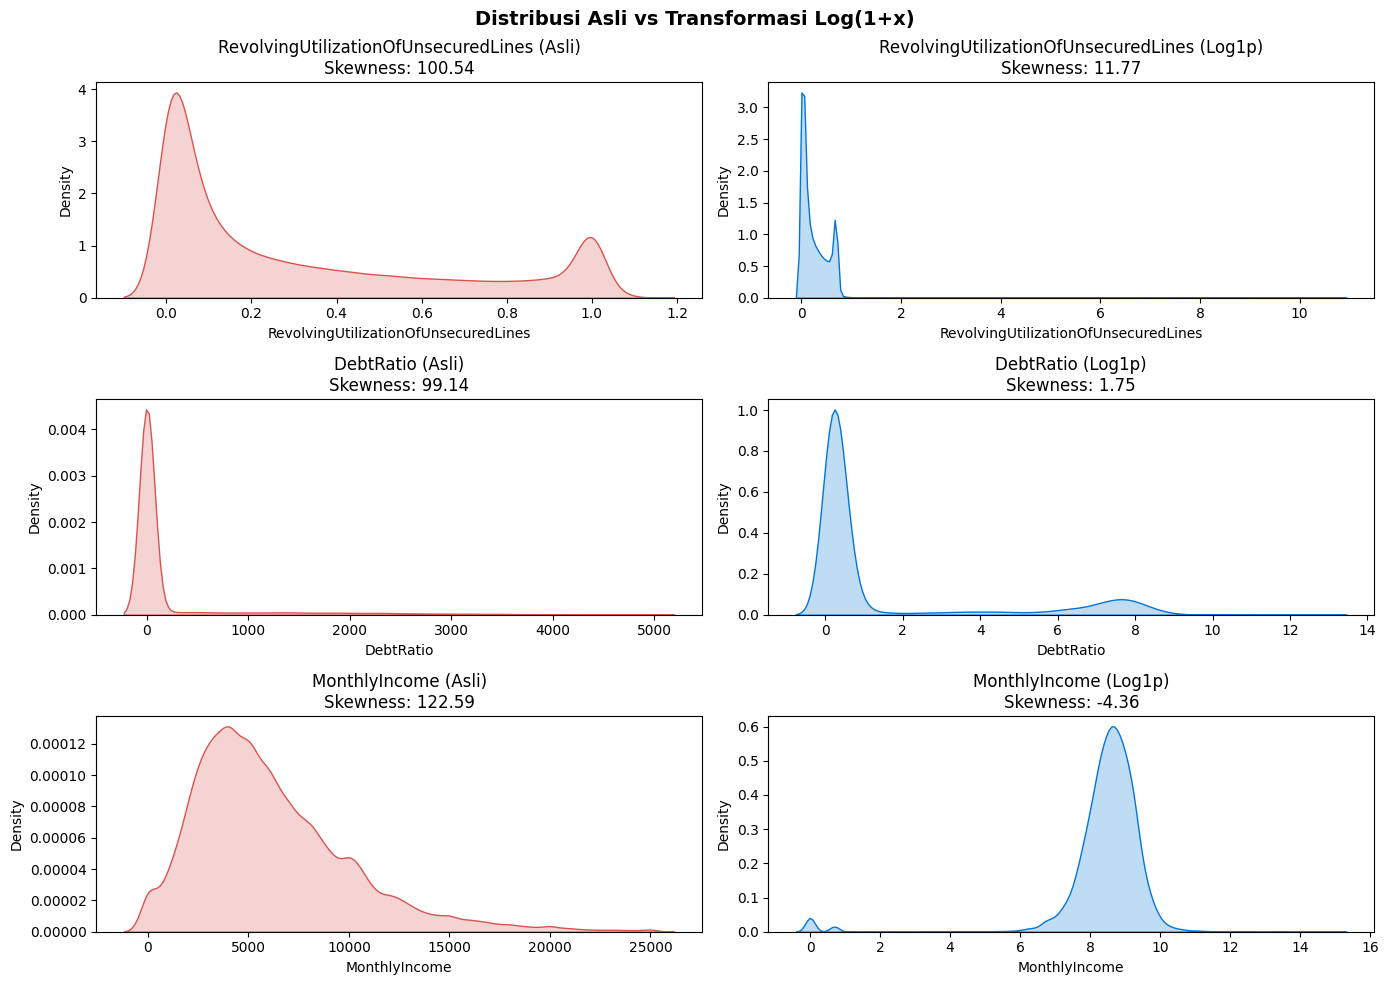

In [ ]:
skewed_cols = ['RevolvingUtilizationOfUnsecuredLines', 'DebtRatio', 'MonthlyIncome']
fig, axes = plt.subplots(len(skewed_cols), 2, figsize=(14, 10))
fig.suptitle('Distribusi Asli vs Transformasi Log(1+x)', fontsize=14, fontweight='bold')

for idx, col in enumerate(skewed_cols):
    data_orig = X_train[col].dropna()
    p99 = np.percentile(data_orig, 99)
    sns.kdeplot(data_orig[data_orig <= p99], ax=axes[idx, 0], color='#d9534f', fill=True)
    axes[idx, 0].set_title(f'{col} (Asli)\nSkewness: {skew(data_orig):.2f}')

    data_log = np.log1p(data_orig[data_orig >= 0])
    sns.kdeplot(data_log, ax=axes[idx, 1], color='#0275d8', fill=True)
    axes[idx, 1].set_title(f'{col} (Log1p)\nSkewness: {skew(data_log):.2f}')

plt.tight_layout()
plt.show()

/tmp/ipykernel_2183/385287490.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=vif_data, x='VIF', y='Feature', palette=colors, ax=ax2)


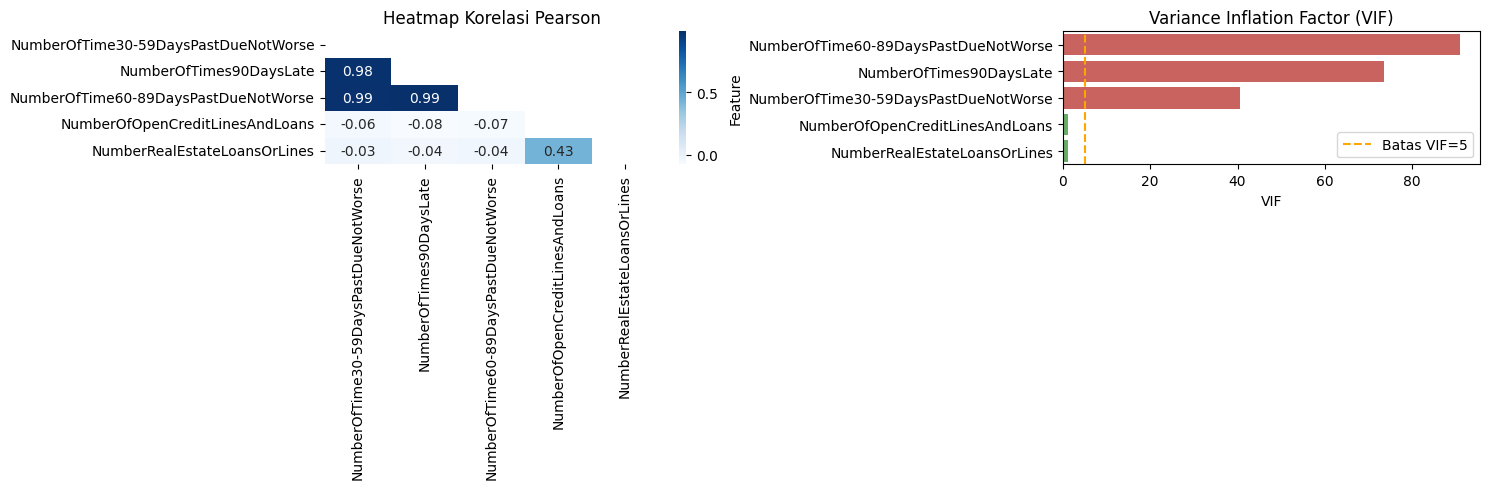

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='Blues', mask=mask, ax=ax1)
ax1.set_title('Heatmap Korelasi Pearson')

colors = ['#d9534f' if v > 5 else '#5cb85c' for v in vif_data['VIF']]
sns.barplot(data=vif_data, x='VIF', y='Feature', palette=colors, ax=ax2)
ax2.axvline(x=5, color='orange', linestyle='--', label='Batas VIF=5')
ax2.set_title('Variance Inflation Factor (VIF)')
ax2.legend()

plt.tight_layout()
plt.show()

/tmp/ipykernel_2183/682592969.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='SeriousDlqin2yrs', y=col_check, palette='Set2')


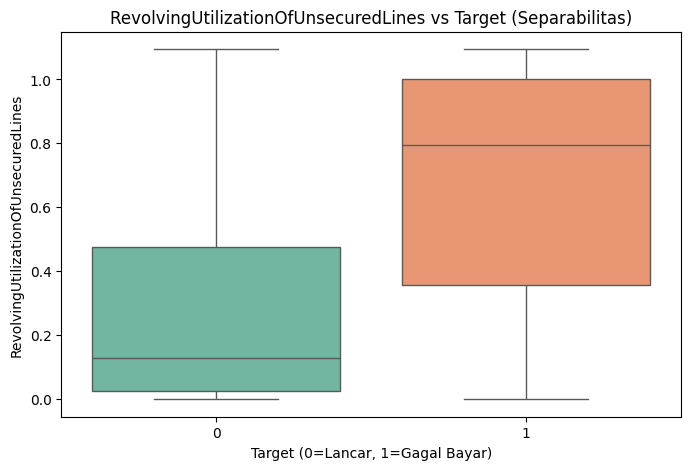

In [ ]:
plt.figure(figsize=(8, 5))
plot_data = X_train[[col_check]].join(y_train)
plot_data = plot_data[plot_data[col_check] <= plot_data[col_check].quantile(0.99)]
sns.boxplot(data=plot_data, x='SeriousDlqin2yrs', y=col_check, palette='Set2')
plt.title(f'{col_check} vs Target (Separabilitas)')
plt.xlabel('Target (0=Lancar, 1=Gagal Bayar)')
plt.show()

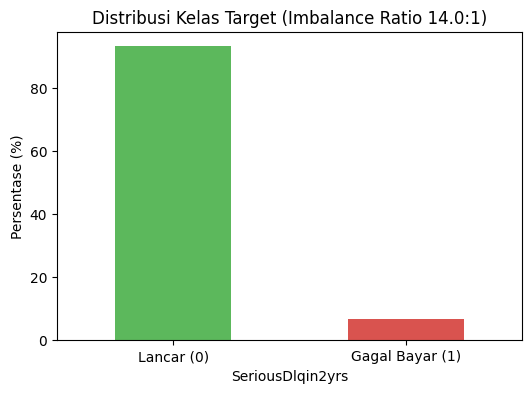

In [ ]:
plt.figure(figsize=(6, 4))
class_pct.plot(kind='bar', color=['#5cb85c', '#d9534f'])
plt.title(f'Distribusi Kelas Target (Imbalance Ratio {imbalance_ratio:.1f}:1)')
plt.ylabel('Persentase (%)')
plt.xticks([0, 1], ['Lancar (0)', 'Gagal Bayar (1)'], rotation=0)
plt.show()

MUHAMMAD IYAD'DIYA ULHQ
